In [1]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=True)
n_states = env.observation_space.n
n_actions = env.action_space.n
random_policy = lambda s: env.action_space.sample()

def generate_episode(env, policy, max_steps=200):
    s, _ = env.reset()
    states, actions, rewards = [], [], []
    for _ in range(max_steps):
        a = policy(s)
        ns, r, term, trunc, _ = env.step(a)
        states.append(s); actions.append(a); rewards.append(r)
        s = ns
        if term or trunc: break
    return states, actions, rewards

def compute_returns(rewards, gamma=0.99):
    G, running = [], 0.0
    for r in reversed(rewards):
        running = r + gamma * running
        G.insert(0, running)
    return G


In [2]:
# Exercise-1.Compare first-visit vs every-visit MC. Do they converge to the same V

def run_both_mc_methods(env, policy, n_episodes=30_000, gamma=0.99):
    V_first = np.zeros(n_states)
    returns_first = {s: [] for s in range(n_states)}
    V_every = np.zeros(n_states)
    returns_every = {s: [] for s in range(n_states)}

    for ep in range(n_episodes):
        states, _, rewards = generate_episode(env, policy)
        G_list = compute_returns(rewards, gamma)
        visited_first = set()

        for s, G in zip(states, G_list):
            returns_every[s].append(G)
            if s not in visited_first:
                visited_first.add(s)
                returns_first[s].append(G)

    for s in range(n_states):
        V_first[s] = np.mean(returns_first[s]) if returns_first[s] else 0
        V_every[s] = np.mean(returns_every[s]) if returns_every[s] else 0
    return V_first, V_every

V_f, V_e = run_both_mc_methods(env, random_policy)
max_diff = np.max(np.abs(V_f - V_e))

print("--- EXERCISE 1 OUTPUT ---")
print(f"Max absolute discrepancy between First-Visit and Every-Visit: {max_diff:.6f}")
print("First-Visit V(s):\n", V_f.reshape(4,4))
print("Every-Visit V(s):\n", V_e.reshape(4,4))


--- EXERCISE 1 OUTPUT ---
Max absolute discrepancy between First-Visit and Every-Visit: 0.009688
First-Visit V(s):
 [[0.01215508 0.0101463  0.0205959  0.0096014 ]
 [0.01406399 0.         0.04109121 0.        ]
 [0.03127884 0.08177884 0.13475483 0.        ]
 [0.         0.17301162 0.43353291 0.        ]]
Every-Visit V(s):
 [[0.01130339 0.01060396 0.01930084 0.01014164]
 [0.01295967 0.         0.0401266  0.        ]
 [0.03108221 0.07807407 0.13834785 0.        ]
 [0.         0.17749615 0.44322084 0.        ]]



--- EXERCISE 2 OUTPUT ---


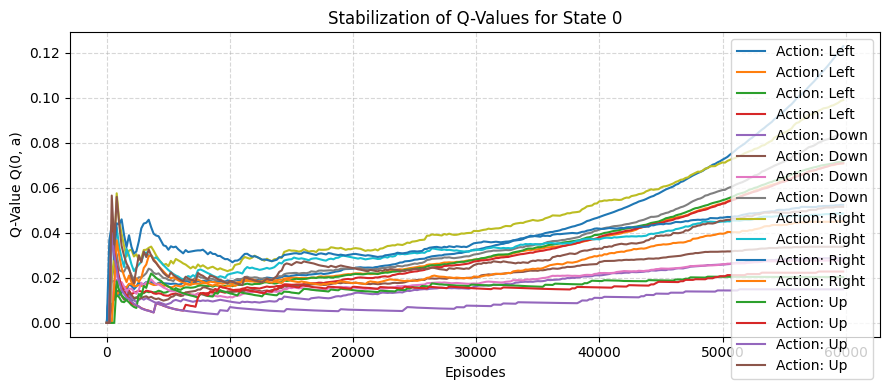

In [3]:
#2-Plot how Q-values for state 0 change over episodes. When do they stabilise?
def mc_control_with_tracking(env, n_episodes=60_000, gamma=0.99, eps_start=1.0, eps_end=0.01):
    Q = np.zeros((n_states, n_actions))
    returns_sum = np.zeros((n_states, n_actions))
    returns_cnt = np.zeros((n_states, n_actions))
    q_space_history = []

    for ep in range(n_episodes):
        eps = max(eps_end, eps_start - ep * (eps_start - eps_end) / n_episodes)
        eps_greedy = lambda s: env.action_space.sample() if np.random.rand() < eps else np.argmax(Q[s])
        states, actions, rewards = generate_episode(env, eps_greedy)
        G_list = compute_returns(rewards, gamma)
        visited = set()

        for s, a, G in zip(states, actions, G_list):
            if (s, a) not in visited:
                visited.add((s, a))
                returns_sum[s, a] += G
                returns_cnt[s, a] += 1
                Q[s, a] = returns_sum[s, a] / returns_cnt[s, a]
        if ep % 200 == 0:
            q_space_history.append((ep, Q.copy()))
    return Q, q_space_history

Q_final, q_hist = mc_control_with_tracking(env)
episodes, q_vals = zip(*q_hist)
q_vals = np.array(q_vals)
actions_labels = ['Left', 'Down', 'Right', 'Up']

print("\n--- EXERCISE 2 OUTPUT ---")
plt.figure(figsize=(9, 4))
for a in range(n_actions):
    plt.plot(episodes, q_vals[:, a], label=f'Action: {actions_labels[a]}', linewidth=1.5)
plt.xlabel('Episodes')
plt.ylabel('Q-Value Q(0, a)')
plt.title('Stabilization of Q-Values for State 0')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [4]:
#Challenge: implement off-policy MC with importance sampling. Evaluate a target policy (greedy) while following a behaviour policy (random).
def off_policy_mc_prediction(env, target_policy_arr, n_episodes=100_000, gamma=0.99):
    V = np.zeros(n_states)
    returns = {s: [] for s in range(n_states)}
    b_prob = 1.0 / n_actions

    for ep in range(n_episodes):
        states, actions, rewards = generate_episode(env, random_policy)
        G_list = compute_returns(rewards, gamma)
        W = 1.0

        for t in reversed(range(len(states))):
            s = states[t]
            a = actions[t]
            G = G_list[t]
            returns[s].append(W * G)
            if a != target_policy_arr[s]:
                break
            W *= (1.0 / b_prob)

    for s in range(n_states):
        V[s] = np.mean(returns[s]) if returns[s] else 0.0
    return V

target_greedy = np.argmax(Q_final, axis=1)
V_target = off_policy_mc_prediction(env, target_greedy)

print("\n--- EXERCISE 3 OUTPUT ---")
print("Target Greedy Policy (Actions per state):\n", target_greedy.reshape(4,4))
print("Target Policy Estimated Value Function V(s):\n", V_target.reshape(4, 4))



--- EXERCISE 3 OUTPUT ---
Target Greedy Policy (Actions per state):
 [[0 3 0 3]
 [0 0 0 0]
 [3 1 0 0]
 [0 2 1 0]]
Target Policy Estimated Value Function V(s):
 [[17.08445283  0.14222155  1.8843976   0.        ]
 [ 0.02380106  0.          0.10344878  0.        ]
 [ 6.54005181  1.51263172  1.27307361  0.        ]
 [ 0.          0.69270817  2.00484653  0.        ]]
